# Multi-Source OOD Diagnostics

This notebook combines empirical data and simulated observed datasets from the four RDM source models.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_DIR = Path("/Users/yimingzang/Documents/Project/benchmark2")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from benchmark.examples.diffusion.config import FIGURE_DIR, TrainingConfig
from benchmark.examples.diffusion.results.multisource_pipeline import compute_or_load_all_observed
from benchmark.examples.diffusion.results.plots import (
    plot_logml_error_vs_rho,
    plot_pmp_error_vs_log_ambiguity,
    plot_pmp_error_vs_rho,
    plot_posterior_metric_vs_rho,
)


INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [3]:
summary_configs = {
    "S=D": TrainingConfig(summary_multiplier=1),
    "S=2D": TrainingConfig(summary_multiplier=2),
    "S=4D": TrainingConfig(summary_multiplier=4),
}

metric = "l2"
num_samples = 2048
mmd_samples = 512
batch_size = 8
recompute = False
recompute_references = False


## Compute Or Load Diagnostics

In [4]:
diagnostics_by_summary = {}

for label, config in summary_configs.items():
    print(label)
    diagnostics_by_summary[label] = compute_or_load_all_observed(
        config,
        metric=metric,
        num_samples=num_samples,
        mmd_samples=mmd_samples,
        batch_size=batch_size,
        recompute=recompute,
        recompute_references=recompute_references,
    )


S=D
S=2D
S=4D


In [5]:
diagnostics_by_summary["S=D"]["diagnostic"].head()

,dataset,id,log_ml_m0,importance_ess_m0,log_ml_m1,importance_ess_m1,log_ml_m2,importance_ess_m2,log_ml_m3,importance_ess_m3,...,dm_high_m3,regime_m3,closest_summary_model,d_min,d_second,summary_ambiguity_true,globally_high_surprise,at_least_one_not_high_surprise,summary_ambiguity,log1p_summary_ambiguity
0,empirical,p0,72.357632,6.501824,88.378122,16.047783,70.922583,7.303614,85.763663,4.808527,...,1.657974,in_distribution,m3,1.180953,1.446673,3.763355,False,True,0.0,0.0
1,empirical,p1,10.615712,11.172754,77.815746,3.339495,12.164792,3.159599,78.165364,4.653611,...,1.657974,in_distribution,m3,1.505627,1.594190,11.291361,False,True,0.0,0.0
2,empirical,p2,-9.424879,34.183272,39.331178,7.457453,4.743121,18.549506,48.566150,1.325322,...,1.657974,in_distribution,m3,1.398611,1.718087,3.130120,False,True,0.0,0.0
3,empirical,p3,168.455779,6.001023,195.490933,8.871487,167.976729,2.395007,197.852249,1.876278,...,1.657974,in_distribution,m3,1.386009,1.626592,4.156569,False,True,0.0,0.0
4,empirical,p4,147.330774,97.537420,225.423897,26.582907,147.330888,2.436712,222.485981,7.400823,...,1.657974,in_distribution,m3,1.404055,1.660283,3.902785,False,True,0.0,0.0


## Single Summary Dimension Plots

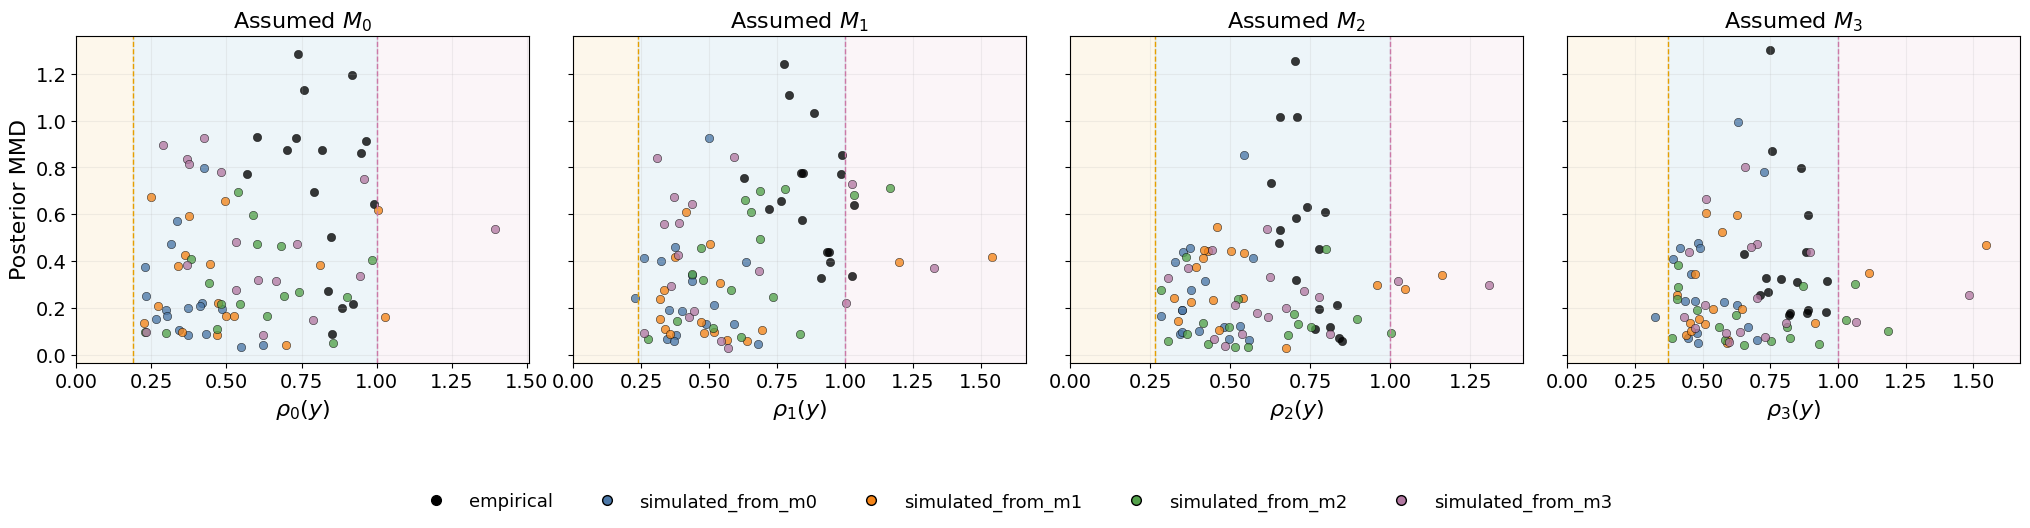

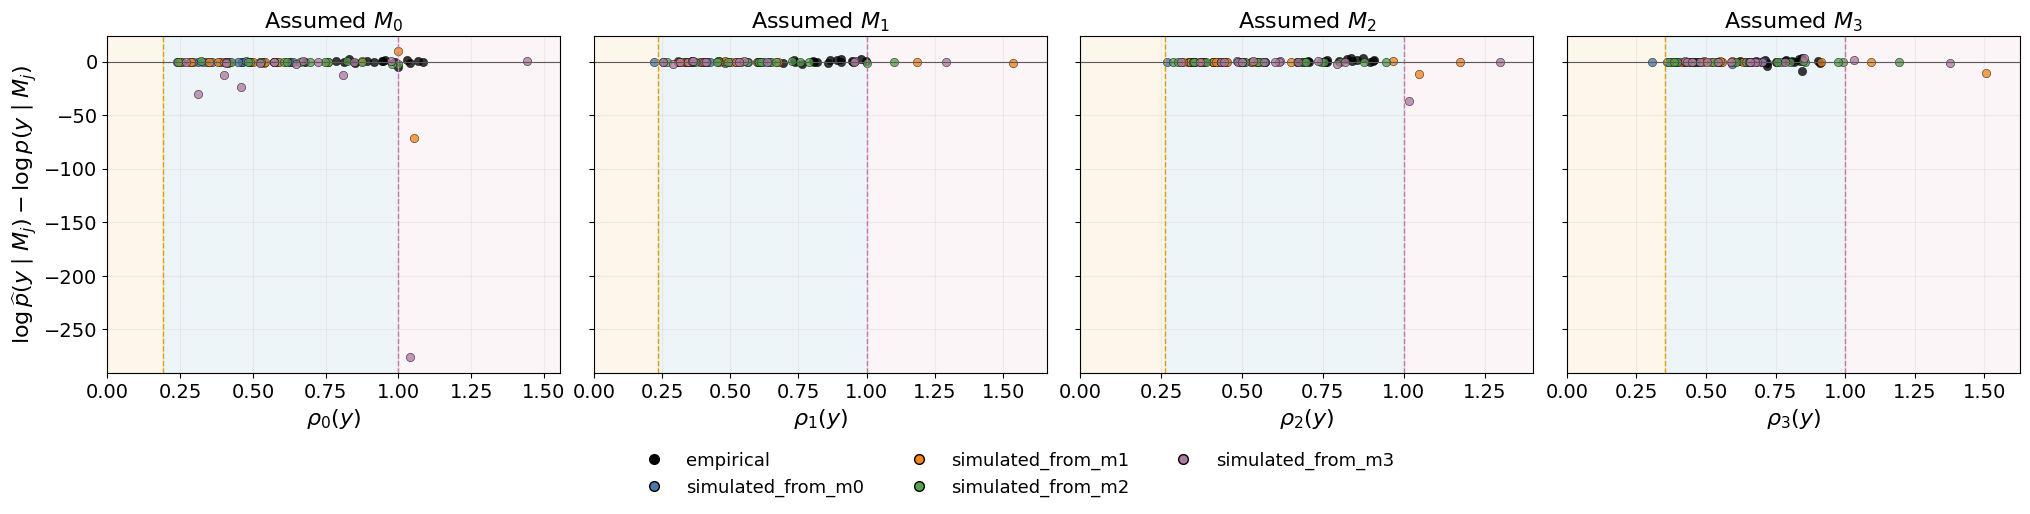

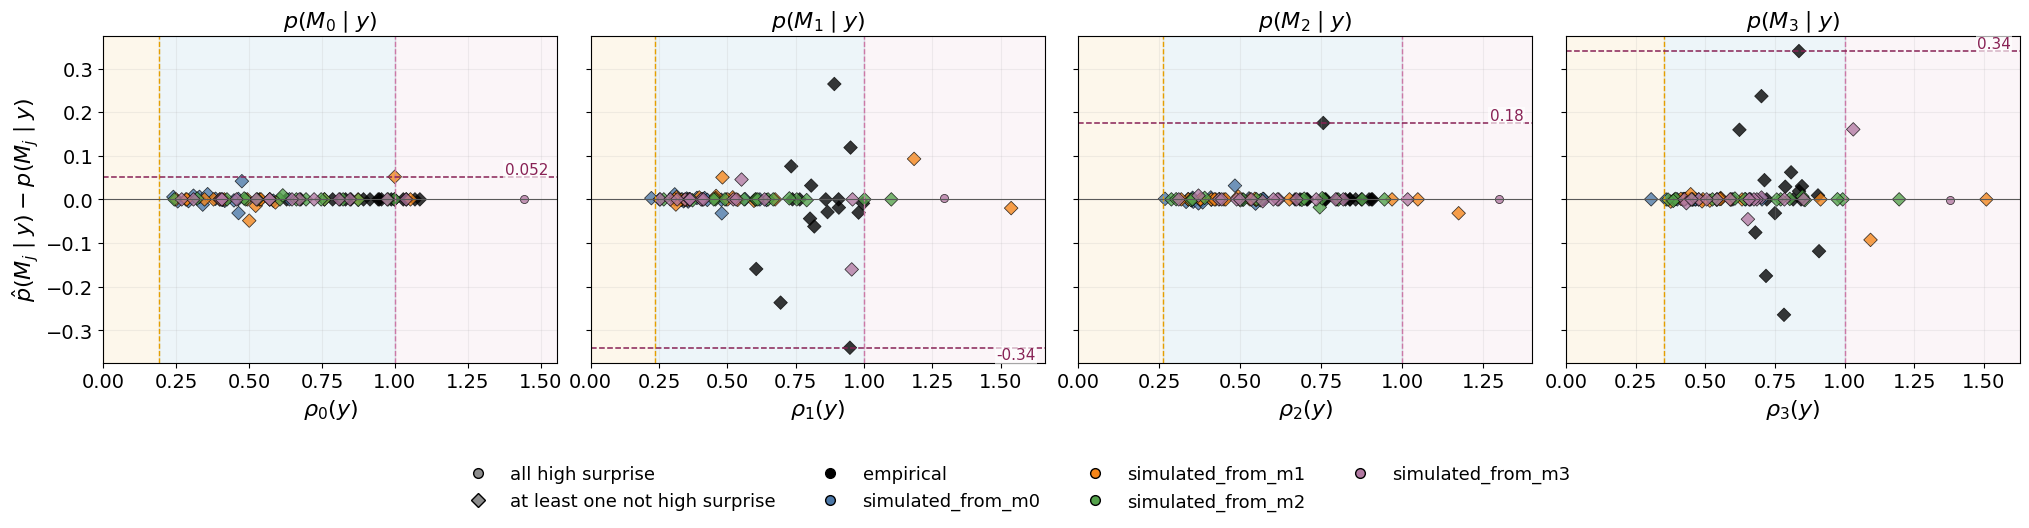

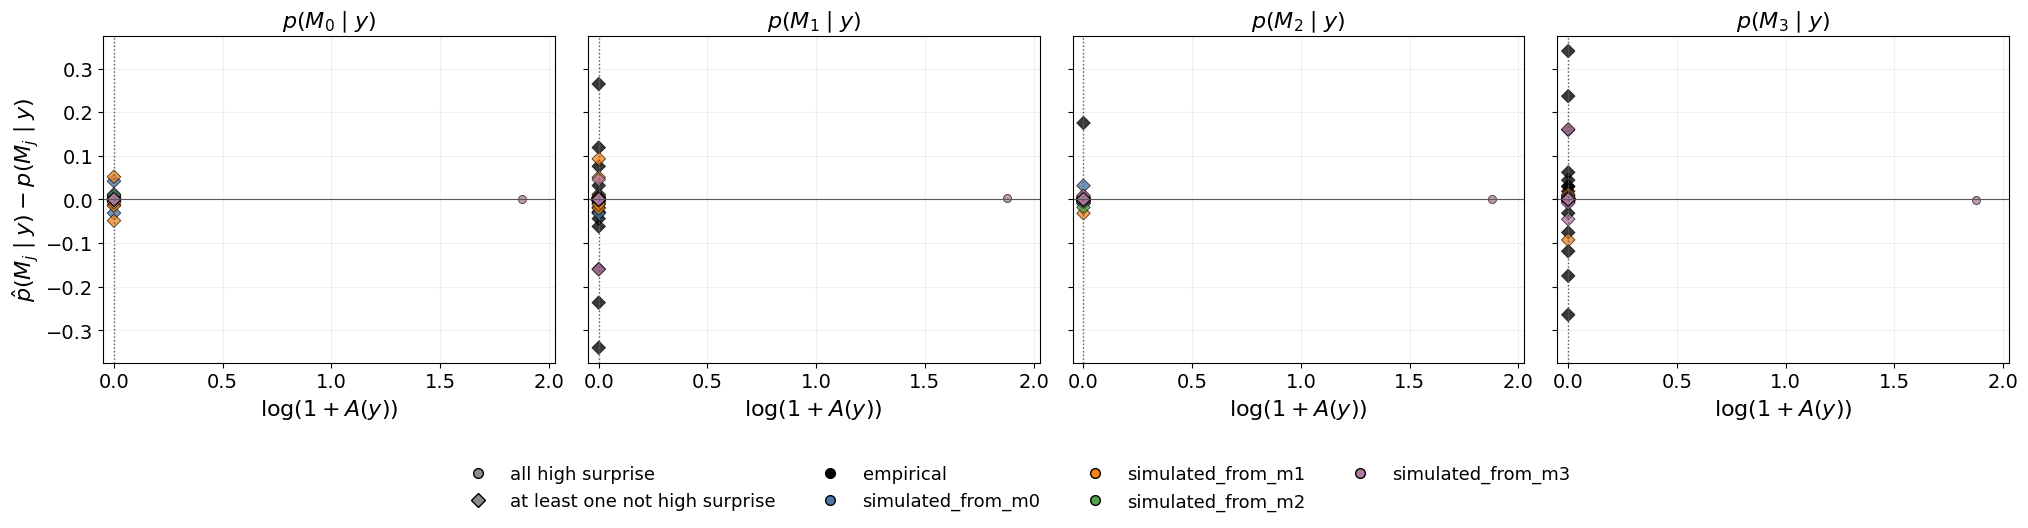

In [6]:
label = "S=D"
tag = summary_configs[label].summary_label
diagnostic = diagnostics_by_summary[label]["diagnostic"]
posterior_plot = diagnostics_by_summary[label]["posterior_plot"]

plot_posterior_metric_vs_rho(
    posterior_plot,
    metric="posterior_mmd",
    ylabel="Posterior MMD",
    filename=f"multi_source_posterior_mmd_vs_rho_{tag}.png",
);
plot_logml_error_vs_rho(diagnostic, filename=f"multi_source_logml_error_vs_rho_{tag}.png");
plot_pmp_error_vs_rho(diagnostic, filename=f"multi_source_pmp_error_vs_rho_{tag}.png");
plot_pmp_error_vs_log_ambiguity(diagnostic, filename=f"multi_source_pmp_error_vs_log_ambiguity_{tag}.png");


## Repeat For All Summary Dimensions

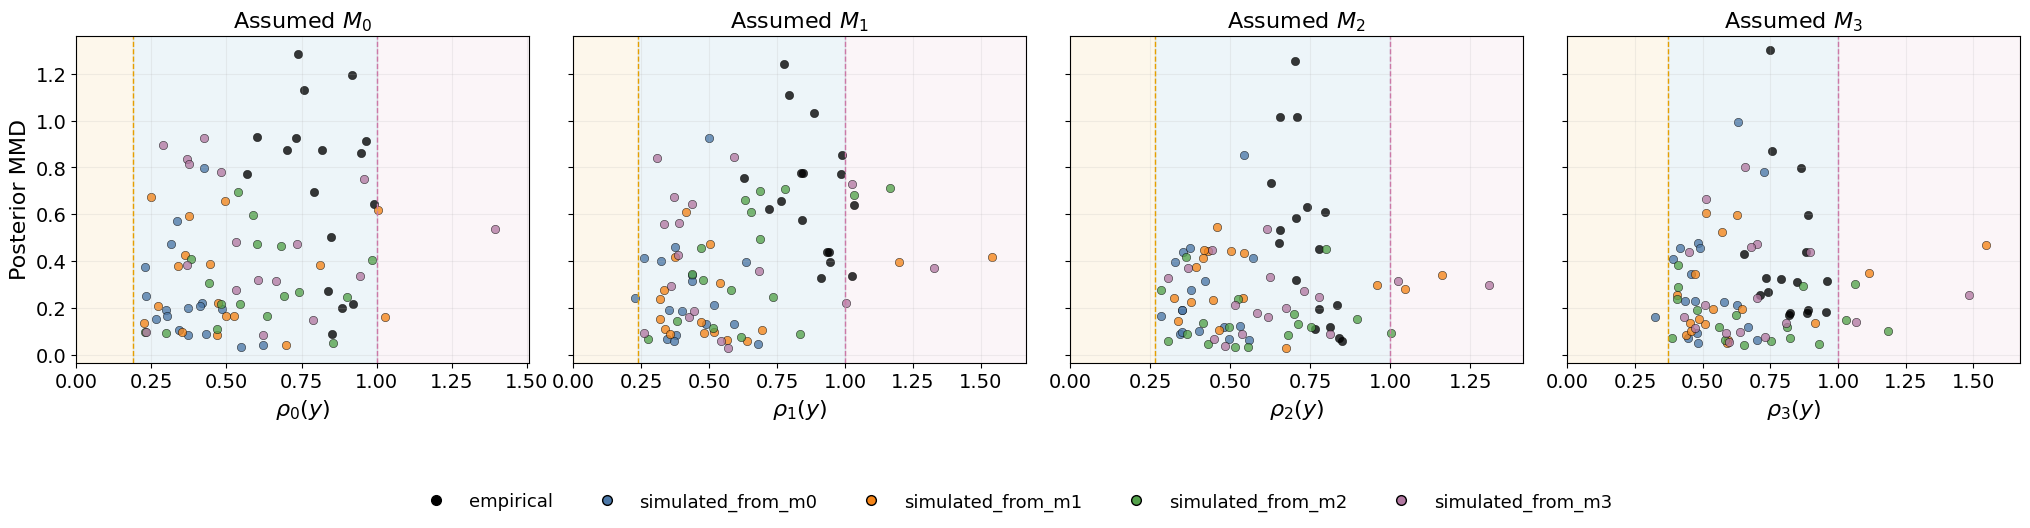

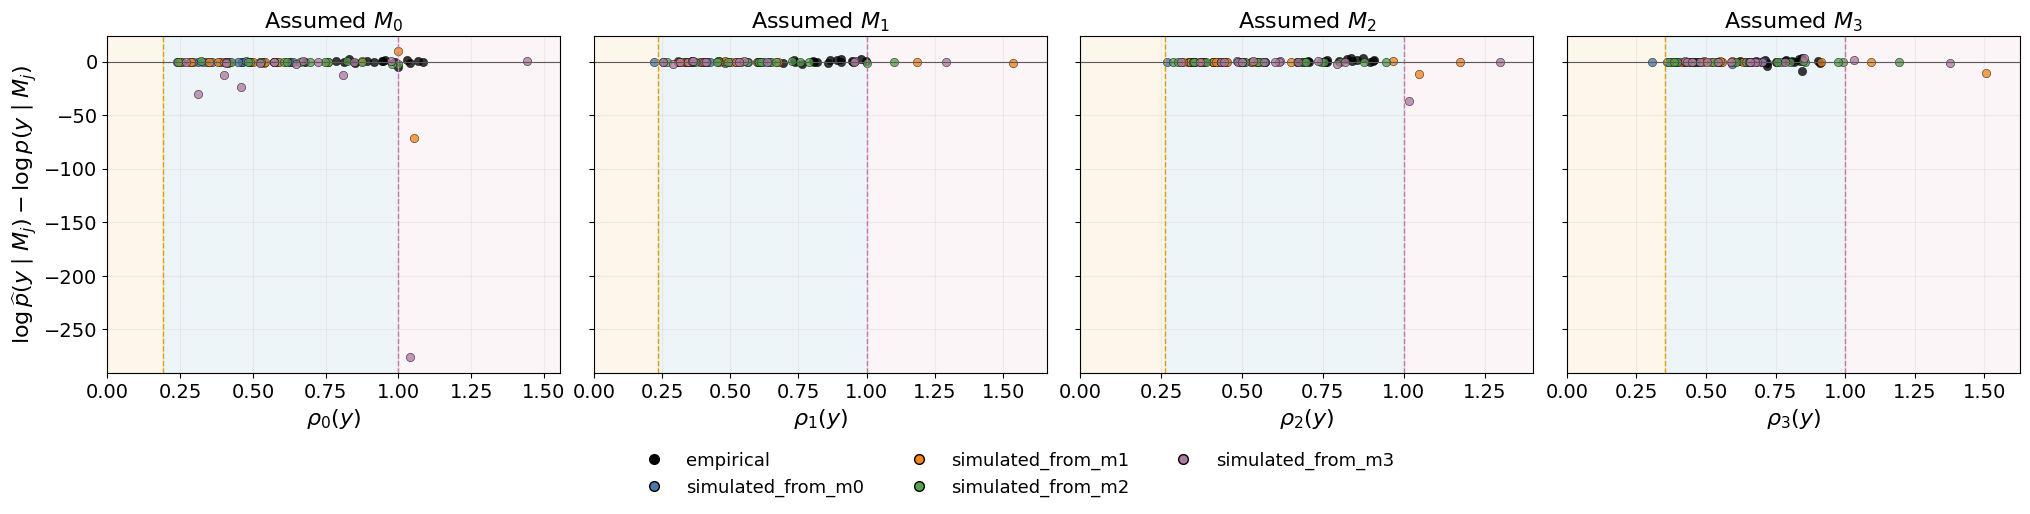

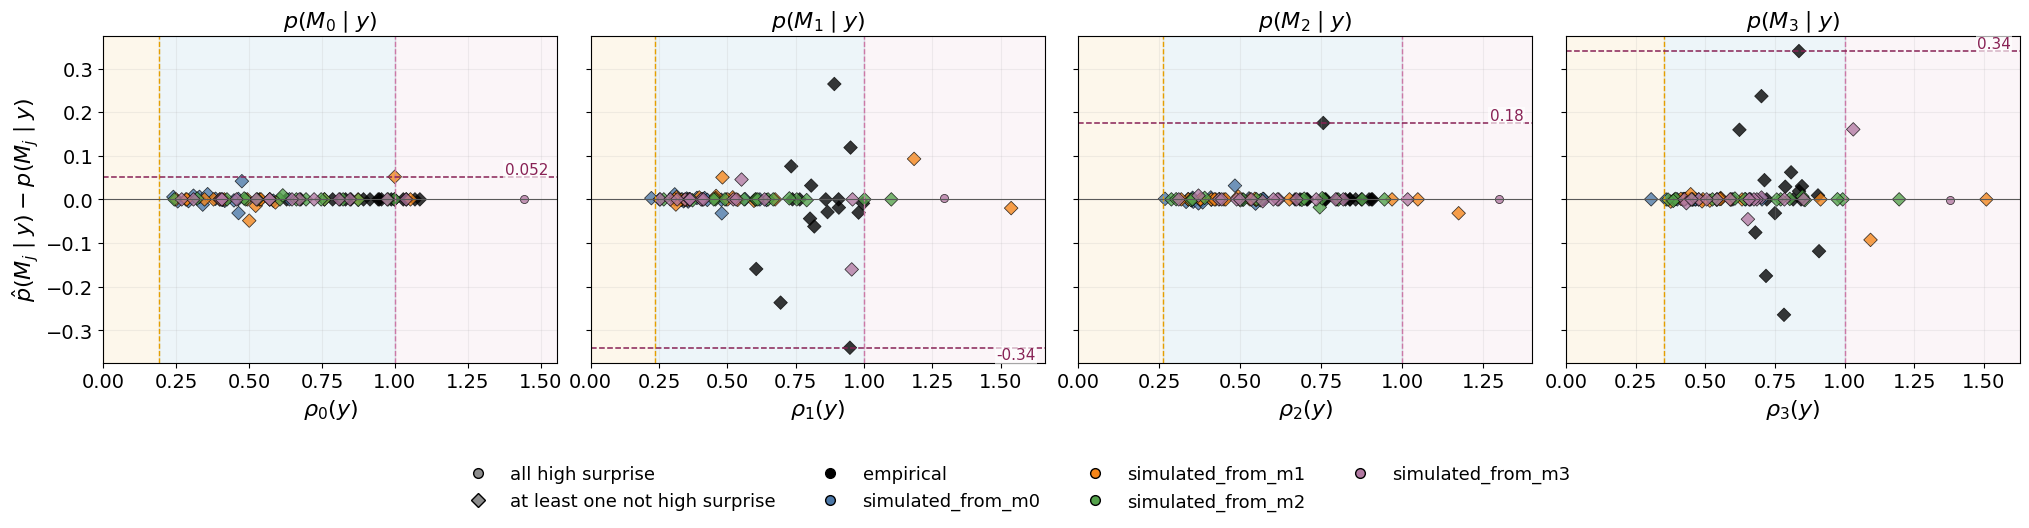

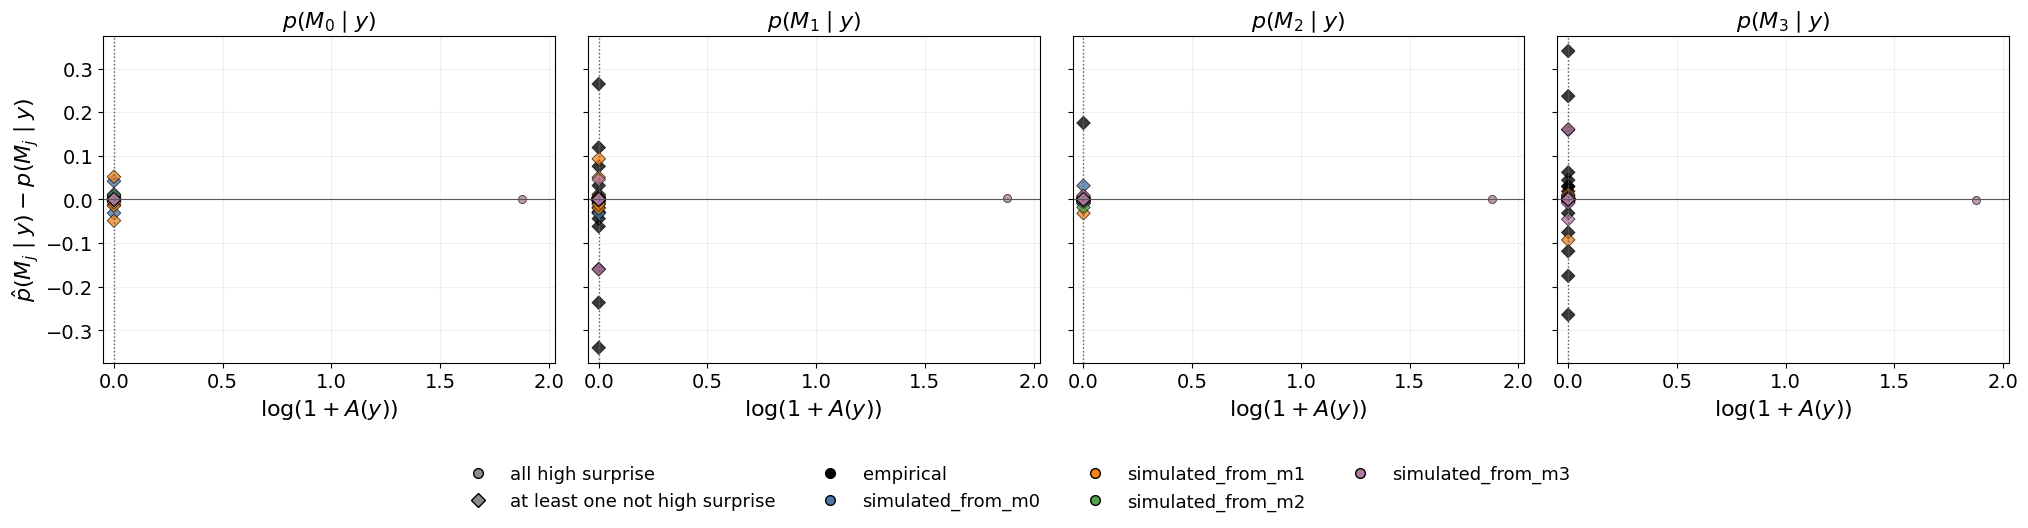

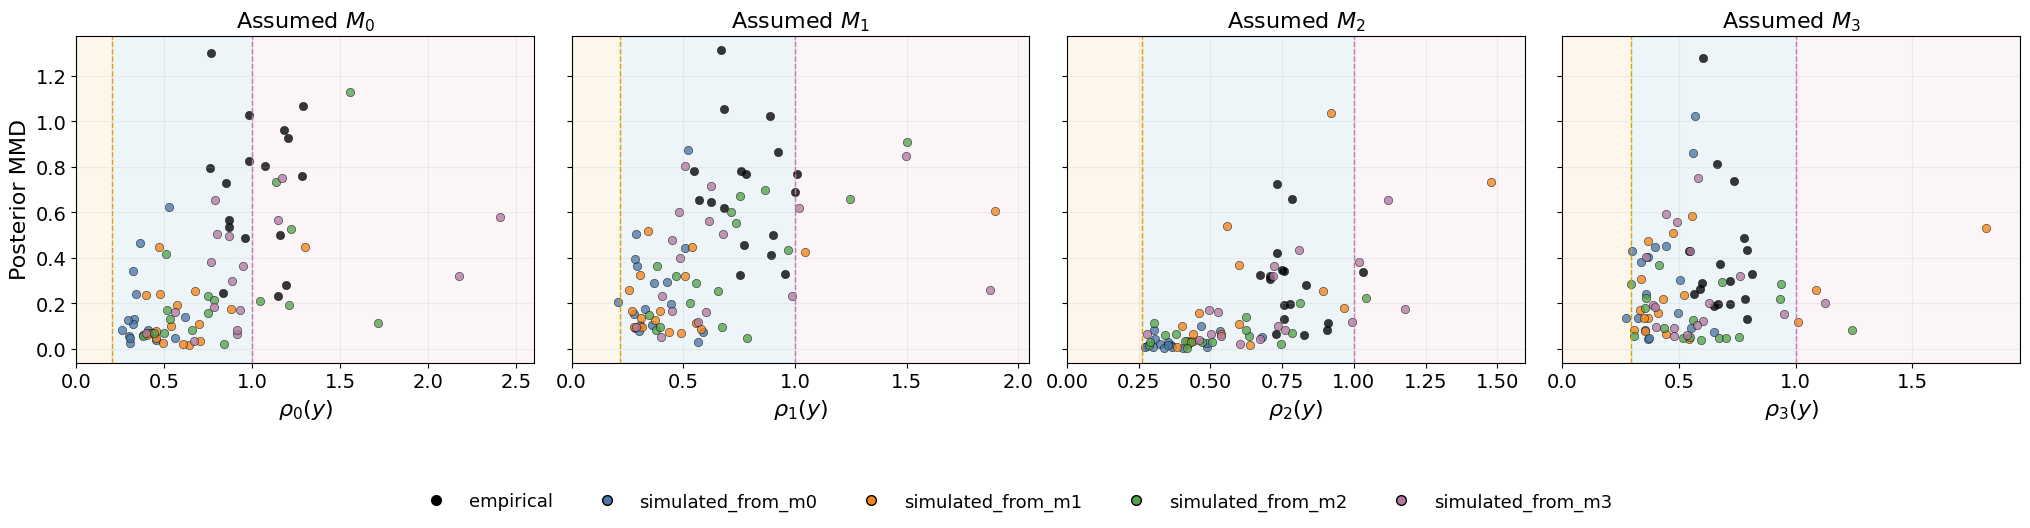

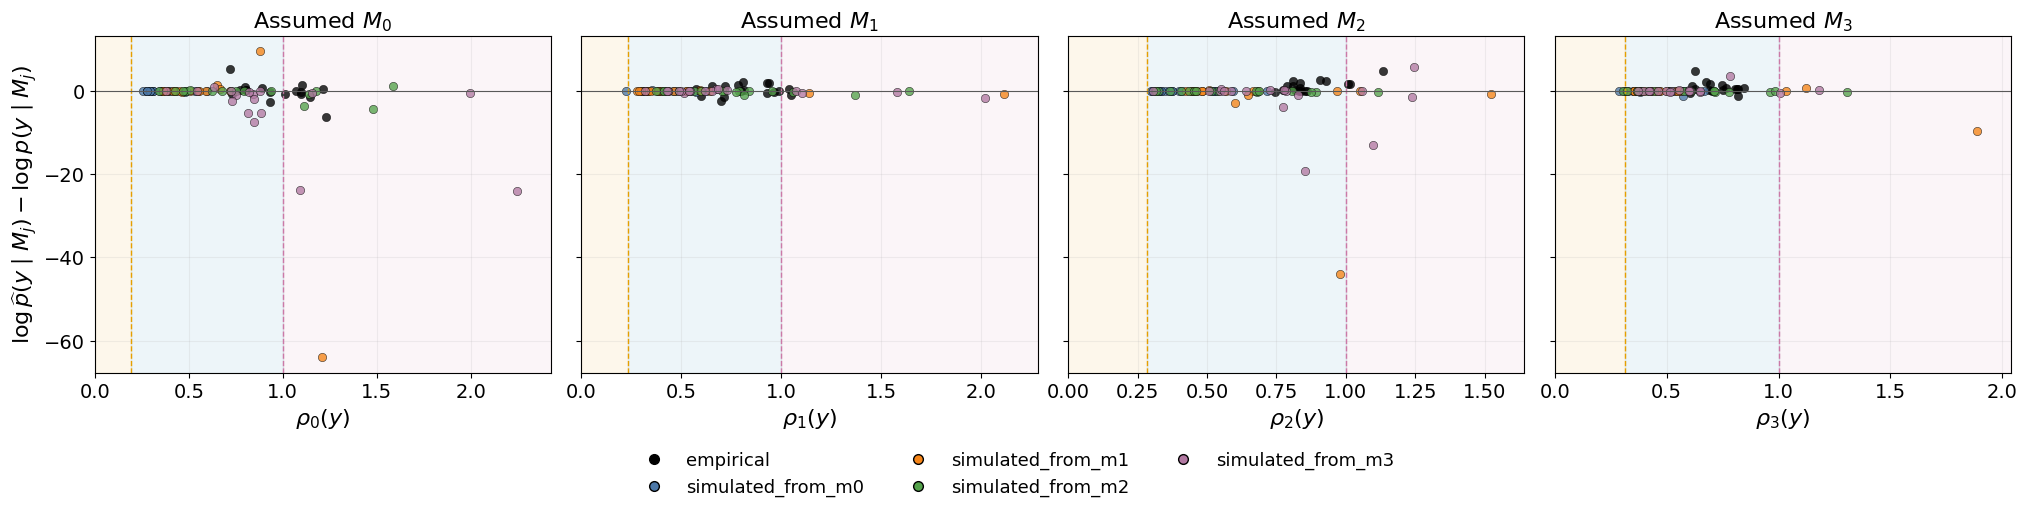

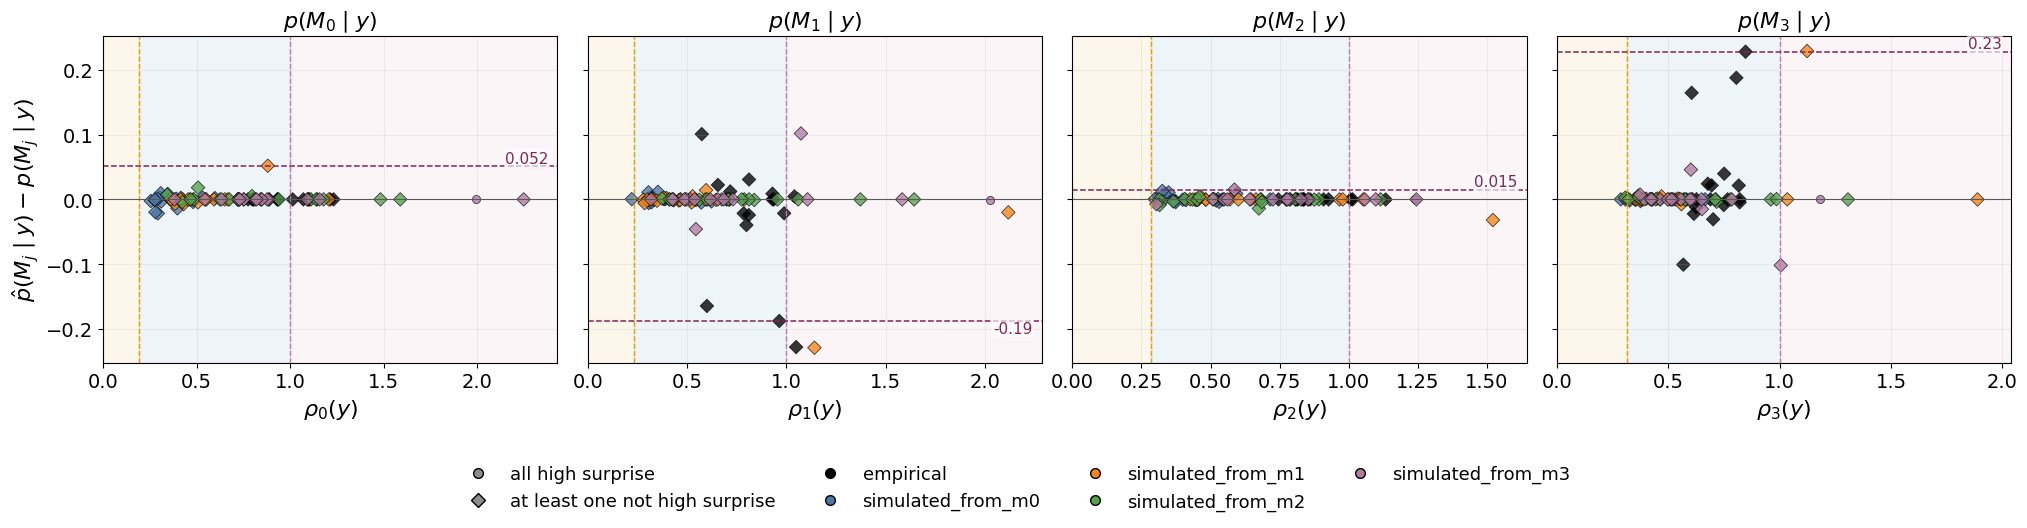

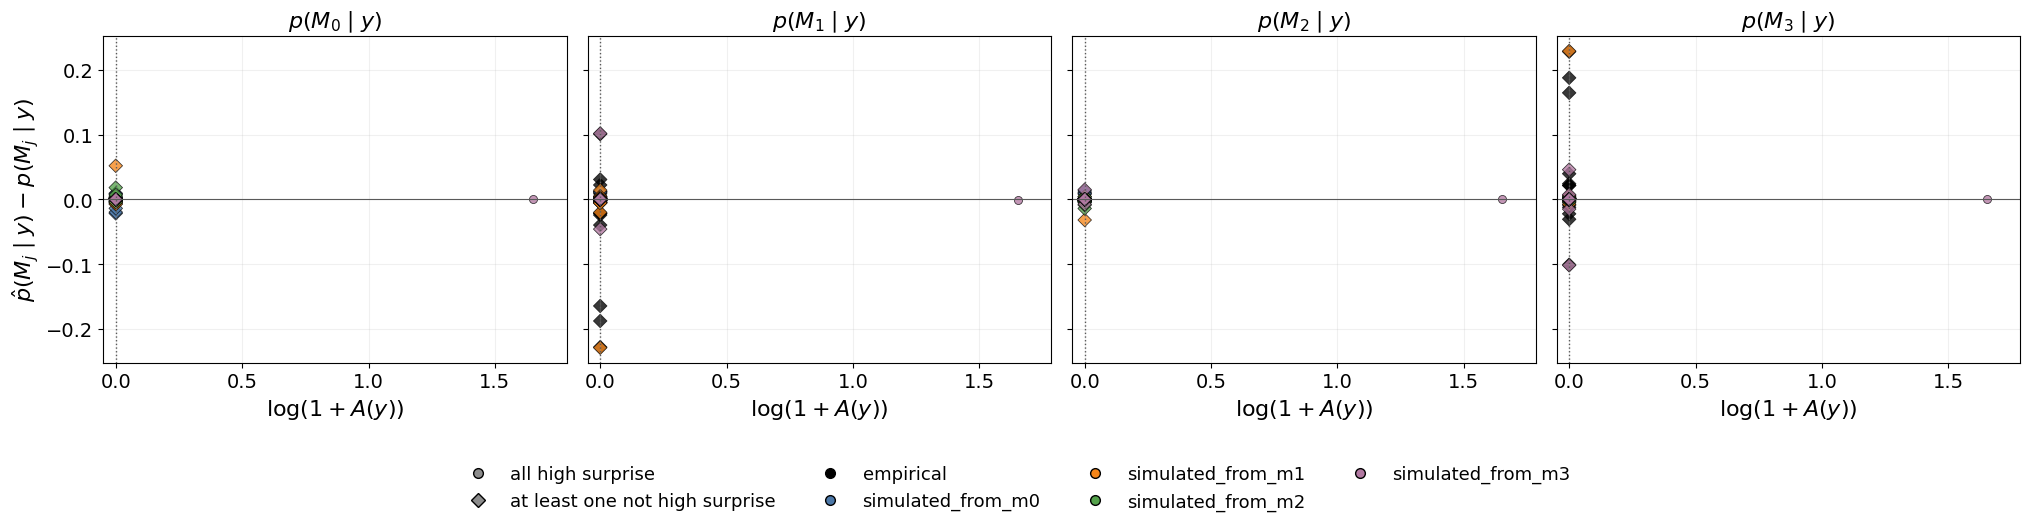

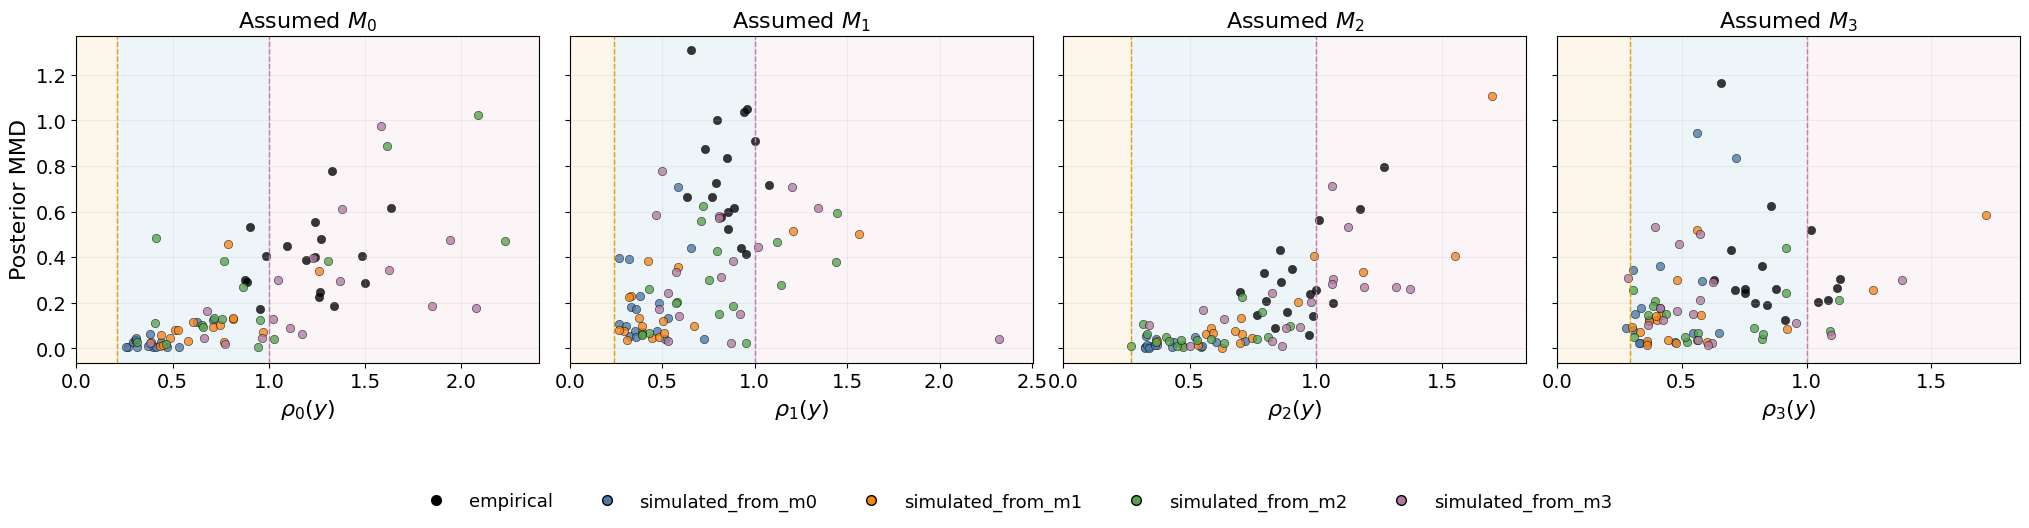

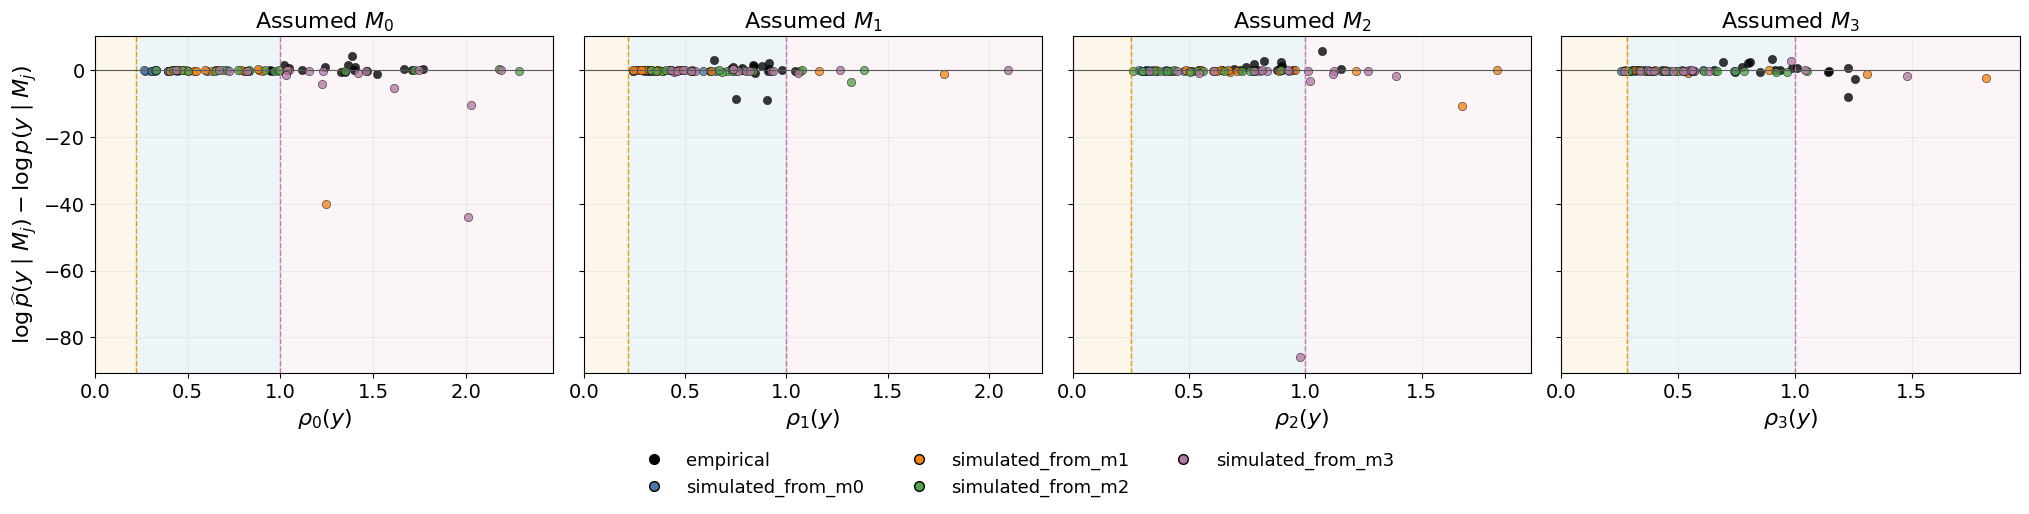

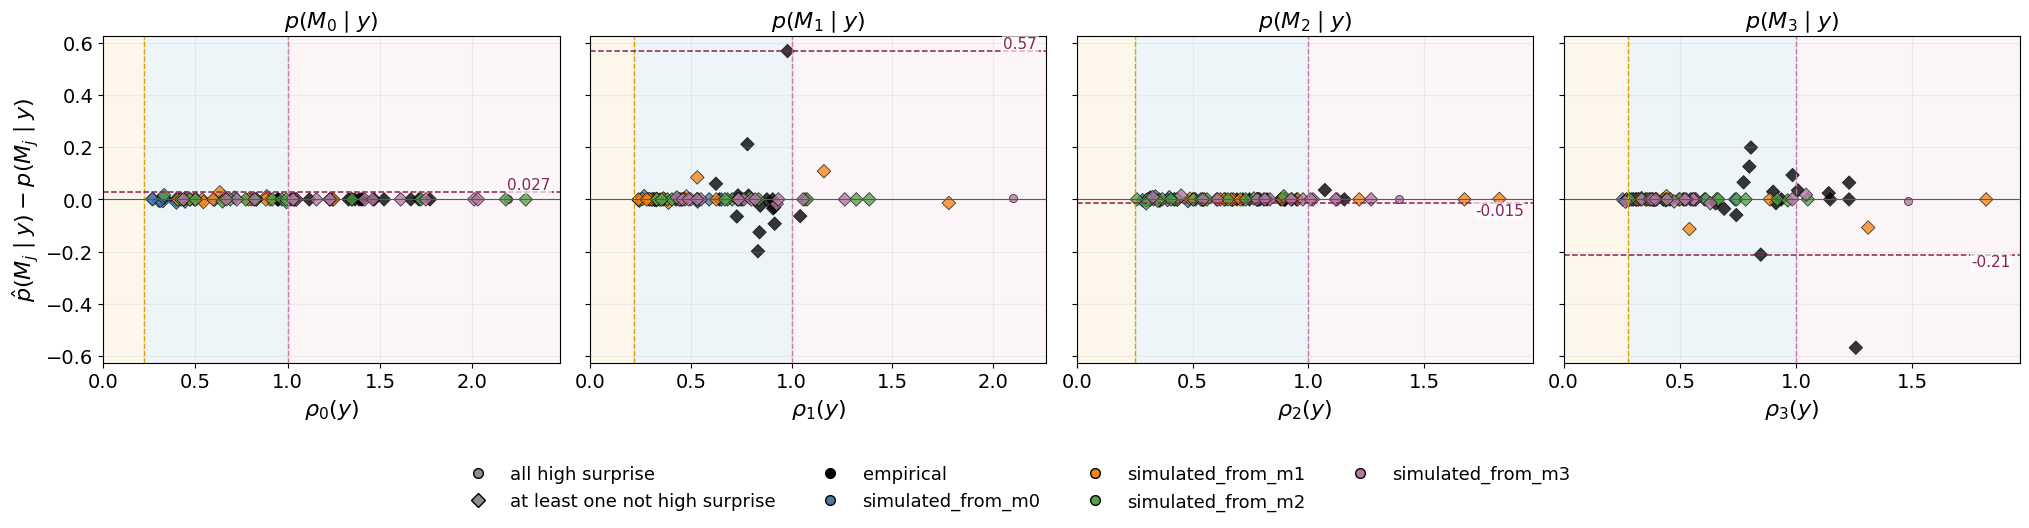

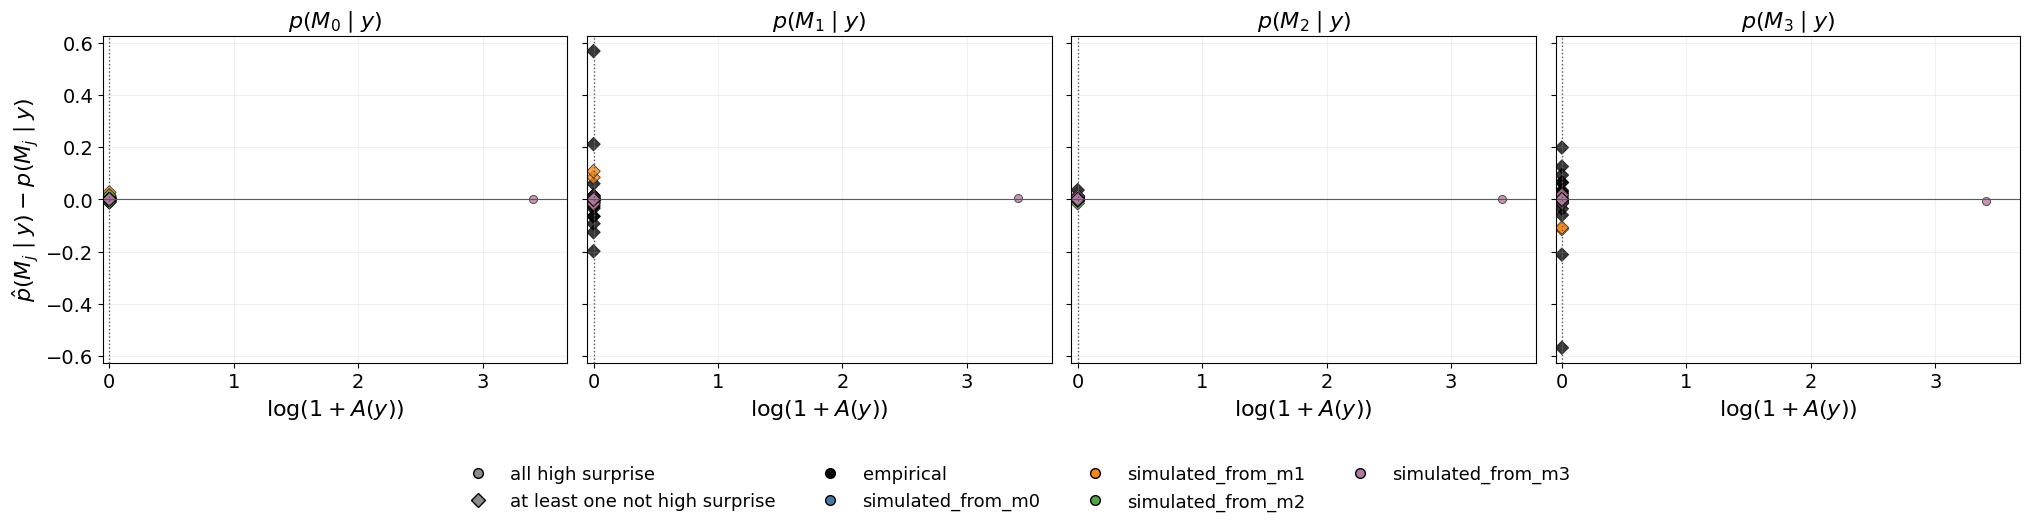

In [7]:
for label, config in summary_configs.items():
    tag = config.summary_label
    diagnostic = diagnostics_by_summary[label]["diagnostic"]
    posterior_plot = diagnostics_by_summary[label]["posterior_plot"]

    plot_posterior_metric_vs_rho(
        posterior_plot,
        metric="posterior_mmd",
        ylabel="Posterior MMD",
        filename=f"multi_source_posterior_mmd_vs_rho_{tag}.png",
    );
    plot_logml_error_vs_rho(diagnostic, filename=f"multi_source_logml_error_vs_rho_{tag}.png");
    plot_pmp_error_vs_rho(diagnostic, filename=f"multi_source_pmp_error_vs_rho_{tag}.png");
    plot_pmp_error_vs_log_ambiguity(diagnostic, filename=f"multi_source_pmp_error_vs_log_ambiguity_{tag}.png");


## Tables

In [8]:
posterior_summary = []
for label, frames in diagnostics_by_summary.items():
    frame = frames["posterior"]
    posterior_summary.append(
        frame.groupby(["dataset", "model"], sort=False)
        .agg(
            mean_mmd=("posterior_mmd", "mean"),
            median_mmd=("posterior_mmd", "median"),
            mean_posterior_mean_rmse=("posterior_mean_rmse", "mean"),
        )
        .assign(summary_dimension=label)
        .reset_index()
    )

posterior_summary = pd.concat(posterior_summary, ignore_index=True)
posterior_summary

,dataset,model,mean_mmd,median_mmd,mean_posterior_mean_rmse,summary_dimension
0,empirical,m0,0.728033,0.861514,0.746658,S=D
1,empirical,m1,0.690397,0.656830,0.704448,S=D
2,empirical,m2,0.493051,0.474762,0.477593,S=D
3,empirical,m3,0.419192,0.313228,0.388432,S=D
4,simulated_from_m0,m0,0.243612,0.195992,0.295187,S=D
5,simulated_from_m0,m1,0.269498,0.210493,0.301742,S=D
6,simulated_from_m0,m2,0.255602,0.188962,0.288926,S=D
7,simulated_from_m0,m3,0.315093,0.226926,0.300444,S=D
8,simulated_from_m1,m0,0.317023,0.222154,0.410933,S=D
9,simulated_from_m1,m1,0.237462,0.151596,0.250993,S=D
